# 🔧 Day 25: GPU FinOps & Cost Optimization - Hands-on Lab

This notebook connects to a local Docker Compose cluster (via ngrok/cloudflared tunnel) to demonstrate:
1. **GPU Cluster Monitoring** - Real-time GPU metrics
2. **Cost Tracking (OpenCost-like)** - Per-node cost allocation & waste analysis
3. **Spot Instance Management** - Bidding, preemption, savings
4. **Autoscaling (KEDA-like)** - Policy-based GPU scaling
5. **Budget Management & Forecasting** - Alerts, burn rate

## Prerequisites
- Docker Compose running locally with the GPU FinOps Lab services
- Tunnel exposed via ngrok or cloudflared (free tier)

In [1]:
# Cell 1: Setup
!pip install -q requests pandas matplotlib plotly

import requests
import pandas as pd
import matplotlib.pyplot as plt
import time
import json
from IPython.display import display, HTML, clear_output

In [2]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Võ Thiên Phú"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600336"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%);
                color: white; padding: 15px; border-radius: 10px;
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} |
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [3]:
# Cell 2: Configure Gateway URL
# Replace with your ngrok/cloudflared URL after running the tunnel
GATEWAY_URL = "https://foam-academy-excessive-cure.trycloudflare.com/"  # <-- CHANGE THIS

# Test connection
try:
    r = requests.get(f"{GATEWAY_URL}/", timeout=10)
    print("✅ Connected to GPU FinOps Lab Gateway")
    print(json.dumps(r.json(), indent=2))
except Exception as e:
    print(f"❌ Connection failed: {e}")
    print("Make sure Docker Compose is running and tunnel is active")

✅ Connected to GPU FinOps Lab Gateway
{
  "service": "GPU FinOps Lab Gateway",
  "endpoints": {
    "cluster": "/cluster/*",
    "billing": "/billing/*",
    "spot": "/spot/*",
    "autoscaler": "/autoscaler/*",
    "cost": "/cost/*"
  }
}


---
## Part 1: GPU Cluster Monitoring
Observe the mock GPU cluster state — nodes, utilization, memory, power draw.

In [4]:
# Cell 3: View Cluster Nodes
nodes = requests.get(f"{GATEWAY_URL}/cluster/nodes").json()

print(f"📊 Cluster has {len(nodes)} nodes")
print("=" * 60)

for node_id, gpus in nodes.items():
    print(f"\n🖥️  {node_id}:")
    for gpu in gpus:
        status_icon = "🟢" if gpu['status'] == 'idle' else "🔴"
        print(f"   GPU {gpu['gpu_id']} [{gpu['gpu_type']}] {status_icon} "
              f"Util: {gpu['utilization']:.1f}% | "
              f"Mem: {gpu['memory_used_gb']:.1f}/{gpu['memory_total_gb']}GB | "
              f"Power: {gpu['power_draw_watts']:.0f}W | "
              f"Temp: {gpu['temperature_c']:.0f}°C")

📊 Cluster has 8 nodes

🖥️  node-00:
   GPU 0 [T4] 🔴 Util: 61.4% | Mem: 10.5/16.0GB | Power: 46W | Temp: 69°C
   GPU 1 [T4] 🔴 Util: 87.7% | Mem: 13.9/16.0GB | Power: 44W | Temp: 72°C

🖥️  node-01:
   GPU 0 [A100] 🔴 Util: 89.8% | Mem: 65.1/80.0GB | Power: 187W | Temp: 66°C
   GPU 1 [A100] 🔴 Util: 84.3% | Mem: 40.2/80.0GB | Power: 231W | Temp: 77°C

🖥️  node-02:
   GPU 0 [V100] 🔴 Util: 85.6% | Mem: 19.4/32.0GB | Power: 198W | Temp: 70°C
   GPU 1 [V100] 🟢 Util: 9.8% | Mem: 0.6/32.0GB | Power: 28W | Temp: 36°C

🖥️  node-03:
   GPU 0 [T4] 🔴 Util: 88.9% | Mem: 13.4/16.0GB | Power: 42W | Temp: 63°C
   GPU 1 [T4] 🔴 Util: 73.8% | Mem: 13.6/16.0GB | Power: 65W | Temp: 70°C

🖥️  node-04:
   GPU 0 [T4] 🔴 Util: 82.1% | Mem: 10.4/16.0GB | Power: 47W | Temp: 76°C
   GPU 1 [T4] 🔴 Util: 83.3% | Mem: 12.5/16.0GB | Power: 50W | Temp: 67°C

🖥️  node-05:
   GPU 0 [T4] 🔴 Util: 86.3% | Mem: 8.5/16.0GB | Power: 49W | Temp: 59°C
   GPU 1 [T4] 🔴 Util: 67.6% | Mem: 12.5/16.0GB | Power: 59W | Temp: 82°C

🖥️  node-

In [5]:
# Cell 4: Cluster Metrics Summary
metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()

print("📈 Cluster Metrics")
print("=" * 40)
print(f"Total GPUs:          {metrics['total_gpus']}")
print(f"Busy GPUs:           {metrics['busy_gpus']}")
print(f"Idle GPUs:           {metrics['idle_gpus']}")
print(f"Avg Utilization:     {metrics['avg_utilization']:.1f}%")
print(f"Memory Used:         {metrics['total_memory_used_gb']:.1f} GB")
print(f"Memory Capacity:     {metrics['total_memory_capacity_gb']:.1f} GB")
print(f"Total Power Draw:    {metrics['total_power_draw_watts']:.0f} W")
print(f"Node Count:          {metrics['node_count']}")

📈 Cluster Metrics
Total GPUs:          16
Busy GPUs:           11
Idle GPUs:           5
Avg Utilization:     57.0%
Memory Used:         225.0 GB
Memory Capacity:     416.0 GB
Total Power Draw:    1136 W
Node Count:          8


---
## Part 2: Workload Submission & Cost Tracking
Submit GPU workloads and track their costs in real-time.

In [6]:
# Cell 5: Submit multiple workloads
workloads = [
    {"workload_id": "train-resnet-001", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 300},
    {"workload_id": "train-bert-002", "gpu_type_preferred": "A100", "gpu_count": 1, "duration_seconds": 600},
    {"workload_id": "inference-api-003", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 120},
    {"workload_id": "train-llm-004", "gpu_type_preferred": "A100", "gpu_count": 2, "duration_seconds": 900},
]

print("🚀 Submitting workloads...")
for wl in workloads:
    r = requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json=wl)
    result = r.json()
    print(f"   {wl['workload_id']}: {result['status']} → {result.get('assigned', 'queued')}")

# Check cluster state after submission
print("\n📊 Updated metrics:")
metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   Busy GPUs: {metrics['busy_gpus']}/{metrics['total_gpus']} | Utilization: {metrics['avg_utilization']:.1f}%")

🚀 Submitting workloads...
   train-resnet-001: running → [{'node_id': 'node-06', 'gpu_id': 0}]
   train-bert-002: running → [{'node_id': 'node-02', 'gpu_id': 1}]
   inference-api-003: running → [{'node_id': 'node-06', 'gpu_id': 1}]
   train-llm-004: running → [{'node_id': 'node-07', 'gpu_id': 0}, {'node_id': 'node-07', 'gpu_id': 1}]

📊 Updated metrics:
   Busy GPUs: 16/16 | Utilization: 80.7%


In [7]:
# Cell 6: Record billing for workloads
billing_events = [
    {"workload_id": "train-resnet-001", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 300, "is_spot": False},
    {"workload_id": "train-bert-002", "gpu_type": "A100", "gpu_count": 1, "duration_seconds": 600, "is_spot": False},
    {"workload_id": "inference-api-003", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 120, "is_spot": True},
    {"workload_id": "train-llm-004", "gpu_type": "A100", "gpu_count": 2, "duration_seconds": 900, "is_spot": True},
]

print("💰 Recording billing events...")
for event in billing_events:
    r = requests.post(f"{GATEWAY_URL}/billing/record", json=event)
    result = r.json()
    spot_label = "[SPOT]" if event['is_spot'] else "[ON-DEMAND]"
    print(f"   {event['workload_id']} {spot_label}: ${result['total_cost_usd']:.4f} "
          f"(saved ${result['savings_usd']:.4f})")

# Get billing summary
print("\n📋 Billing Summary:")
summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total Cost:     ${summary['total_cost_usd']:.4f}")
print(f"   Total Savings:  ${summary['total_savings_usd']:.4f}")
print(f"   Budget Used:    {summary['budget_utilization_pct']:.1f}%")
print(f"   Alert Status:   {summary['alert']}")

💰 Recording billing events...
   train-resnet-001 [ON-DEMAND]: $0.0292 (saved $0.0000)
   train-bert-002 [ON-DEMAND]: $0.6117 (saved $0.0000)
   inference-api-003 [SPOT]: $0.0035 (saved $0.0082)
   train-llm-004 [SPOT]: $0.5505 (saved $1.2845)

📋 Billing Summary:
   Total Cost:     $5.2869
   Total Savings:  $5.5380
   Budget Used:    5.3%
   Alert Status:   OK


---
## Part 3: Spot Instance Management
Demonstrate spot bidding, preemption handling, and cost savings.

In [8]:
# Cell 7: Check spot pricing
spot_pricing = requests.get(f"{GATEWAY_URL}/spot/pricing").json()

print("💹 Current Spot Pricing")
print("=" * 60)
print(f"{'GPU Type':<10} {'On-Demand':<12} {'Spot Price':<12} {'Discount':<10} {'Availability'}")
print("-" * 60)
for gpu, info in spot_pricing.items():
    print(f"{gpu:<10} ${info['on_demand_price']:<10.2f} ${info['current_spot_price']:<10.4f} "
          f"{info['discount_pct']:<8.1f}% {info['availability']}")

💹 Current Spot Pricing
GPU Type   On-Demand    Spot Price   Discount   Availability
------------------------------------------------------------
T4         $0.35       $0.2371     32.3    % high
A100       $3.67       $2.2409     38.9    % high
V100       $2.48       $1.3977     43.6    % low


In [9]:
# Cell 8: Request spot instances
spot_requests = [
    {"instance_id": "spot-t4-001", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": "batch-job-1"},
    {"instance_id": "spot-t4-002", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.12, "workload_id": "batch-job-2"},
    {"instance_id": "spot-a100-001", "gpu_type": "A100", "gpu_count": 1, "max_price_per_hour": 1.50, "workload_id": "training-3"},
]

print("🎯 Requesting Spot Instances...")
for req in spot_requests:
    r = requests.post(f"{GATEWAY_URL}/spot/request", json=req)
    result = r.json()
    status_icon = "✅" if result['status'] == 'granted' else "❌"
    print(f"   {status_icon} {req['instance_id']} ({req['gpu_type']}): {result['status']}")
    if result['status'] == 'rejected':
        print(f"      Reason: {result.get('reason', 'N/A')}")

🎯 Requesting Spot Instances...
   ✅ spot-t4-001 (T4): granted
   ✅ spot-t4-002 (T4): granted
   ✅ spot-a100-001 (A100): granted


In [10]:
# Cell 9: Simulate spot preemption
print("⚡ Simulating spot preemption event...")
preemption = requests.post(f"{GATEWAY_URL}/spot/simulate-preemption").json()

print(f"\n   Preempted instances: {preemption['preempted_count']}")
print(f"   Still active: {preemption['total_active']}")

if preemption['preempted_instances']:
    print("\n   ⚠️  Preempted:")
    for p in preemption['preempted_instances']:
        print(f"      - {p['instance_id']} (ran for {p['runtime_seconds']:.0f}s, "
              f"{p['notice_seconds']}s warning)")

# Savings report
print("\n💰 Spot Savings Report:")
savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot cost:        ${savings['total_spot_cost']:.4f}")
print(f"   On-demand equiv:  ${savings['on_demand_equivalent']:.4f}")
print(f"   Total saved:      ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

⚡ Simulating spot preemption event...

   Preempted instances: 1
   Still active: 5

   ⚠️  Preempted:
      - opt-spot-1 (ran for 40s, 120s warning)

💰 Spot Savings Report:
   Spot cost:        $0.0026
   On-demand equiv:  $0.0087
   Total saved:      $0.0061 (70.0%)


---
## Part 4: Autoscaling (KEDA-like)
Configure and trigger GPU autoscaling based on utilization thresholds.

In [11]:
# Cell 10: View and update autoscaling policy
policy = requests.get(f"{GATEWAY_URL}/autoscaler/policy").json()
print("📜 Current Autoscaling Policy:")
for k, v in policy.items():
    print(f"   {k}: {v}")

# Update policy - more aggressive scaling
new_policy = {
    "scale_up_threshold": 70,
    "scale_down_threshold": 25,
    "cooldown_seconds": 30,
    "max_nodes": 10,
    "min_nodes": 2,
    "preferred_gpu_type": "T4",
    "cost_aware": True
}

print("\n🔄 Updating policy...")
updated = requests.post(f"{GATEWAY_URL}/autoscaler/policy", json=new_policy).json()
print("   ✅ Policy updated")

📜 Current Autoscaling Policy:
   scale_up_threshold: 70.0
   scale_down_threshold: 25.0
   cooldown_seconds: 30
   max_nodes: 10
   min_nodes: 2
   preferred_gpu_type: T4
   cost_aware: True

🔄 Updating policy...
   ✅ Policy updated


In [12]:
# Cell 11: Trigger autoscaler evaluation
print("🔄 Evaluating autoscaling decision...")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()

action_icons = {"scale_up": "⬆️", "scale_down": "⬇️", "no_action": "➡️"}
print(f"\n   {action_icons.get(decision['action'], '❓')} Action: {decision['action'].upper()}")
print(f"   Reason: {decision['reason']}")
print(f"   Current utilization: {decision['current_utilization']:.1f}%")
print(f"   Nodes: {decision['node_count']} → {decision['target_node_count']}")

# Run multiple evaluations to show scaling behavior
print("\n📊 Running 5 evaluation cycles...")
for i in range(5):
    time.sleep(2)
    d = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
    print(f"   Cycle {i+1}: {d['action']:<12} | Util: {d['current_utilization']:.1f}% | Nodes: {d['node_count']}→{d['target_node_count']}")

🔄 Evaluating autoscaling decision...

   ⬆️ Action: SCALE_UP
   Reason: Utilization 80.7% > threshold 70.0%
   Current utilization: 80.7%
   Nodes: 8 → 9

📊 Running 5 evaluation cycles...
   Cycle 1: no_action    | Util: 71.8% | Nodes: 9→9
   Cycle 2: no_action    | Util: 71.8% | Nodes: 9→9
   Cycle 3: no_action    | Util: 71.8% | Nodes: 9→9
   Cycle 4: no_action    | Util: 71.8% | Nodes: 9→9
   Cycle 5: no_action    | Util: 71.8% | Nodes: 9→9


---
## Part 5: Cost Analysis & Optimization (OpenCost-like)
Analyze cost allocation, identify waste, and get recommendations.

In [13]:
# Cell 12: Take cost snapshots
print("📸 Taking cost snapshots...")
snapshots = []
for i in range(5):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    snapshots.append(snap)
    print(f"   Snapshot {i+1}: Total=${snap['total_cost_usd']:.6f} | "
          f"Idle=${snap['total_idle_cost_usd']:.6f} | "
          f"Waste={snap['waste_pct']:.1f}%")
    time.sleep(1)

📸 Taking cost snapshots...
   Snapshot 1: Total=$0.047778 | Idle=$0.001944 | Waste=4.1%
   Snapshot 2: Total=$0.047778 | Idle=$0.001944 | Waste=4.1%
   Snapshot 3: Total=$0.047778 | Idle=$0.001944 | Waste=4.1%
   Snapshot 4: Total=$0.047778 | Idle=$0.001944 | Waste=4.1%
   Snapshot 5: Total=$0.047778 | Idle=$0.001944 | Waste=4.1%


In [14]:
# Cell 13: Waste Report
waste = requests.get(f"{GATEWAY_URL}/cost/waste-report").json()

print("🗑️  WASTE ANALYSIS REPORT")
print("=" * 50)
print(f"   Average Waste:          {waste.get('avg_waste_pct', 0):.1f}%")
print(f"   Total Idle Cost:        ${waste.get('total_idle_cost_usd', 0):.6f}")
print(f"   Total Cost:             ${waste.get('total_cost_usd', 0):.6f}")
print(f"   Potential Monthly Save:  ${waste.get('potential_monthly_savings', 0):.2f}")
print(f"   Severity:               {waste.get('severity', 'N/A')}")

🗑️  WASTE ANALYSIS REPORT
   Average Waste:          4.2%
   Total Idle Cost:        $0.019440
   Total Cost:             $0.460279
   Potential Monthly Save:  $503.88
   Severity:               LOW


In [15]:
# Cell 14: Get Optimization Recommendations
recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()

print("💡 COST OPTIMIZATION RECOMMENDATIONS")
print("=" * 60)
for i, rec in enumerate(recs, 1):
    priority_icons = {"HIGH": "🔴", "MEDIUM": "🟡", "LOW": "🟢"}
    icon = priority_icons.get(rec['priority'], '⚪')
    print(f"\n{i}. {icon} [{rec['priority']}] {rec['type']}")
    print(f"   {rec['description']}")
    print(f"   Estimated savings: {rec['estimated_savings_pct']:.1f}%")

💡 COST OPTIMIZATION RECOMMENDATIONS

1. 🟡 [MEDIUM] USE_SPOT
   Switch fault-tolerant workloads to spot instances for 60-70% savings.
   Estimated savings: 65.0%

2. 🟢 [LOW] SCHEDULING
   Schedule non-urgent training jobs during off-peak hours for lower spot prices.
   Estimated savings: 20.0%


In [16]:
# Cell 15: Full Dashboard View
dashboard = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()

print("📊 GPU FinOps DASHBOARD")
print("=" * 60)

cm = dashboard.get('cluster_metrics', {})
print(f"\n🖥️  CLUSTER: {cm.get('total_gpus', 0)} GPUs across {cm.get('node_count', 0)} nodes")
print(f"   Utilization: {cm.get('avg_utilization', 0):.1f}% | Busy: {cm.get('busy_gpus', 0)} | Idle: {cm.get('idle_gpus', 0)}")

bs = dashboard.get('billing_summary', {})
print(f"\n💰 BILLING: ${bs.get('total_cost_usd', 0):.4f} / ${bs.get('budget_usd', 0):.2f} budget")
print(f"   Alert: {bs.get('alert', 'N/A')} | Savings: ${bs.get('total_savings_usd', 0):.4f}")

ss = dashboard.get('spot_savings', {})
print(f"\n🎯 SPOT: Saved ${ss.get('total_savings', 0):.4f} ({ss.get('savings_pct', 0):.1f}%)")

wa = dashboard.get('waste_analysis', {})
if wa:
    print(f"\n🗑️  WASTE: {wa.get('avg_waste_pct', 0):.1f}% | Severity: {wa.get('severity', 'N/A')}")

📊 GPU FinOps DASHBOARD

🖥️  CLUSTER: 18 GPUs across 9 nodes
   Utilization: 71.8% | Busy: 16 | Idle: 2

💰 BILLING: $5.2869 / $100.00 budget
   Alert: OK | Savings: $5.5380

🎯 SPOT: Saved $0.0253 (70.0%)

🗑️  WASTE: 4.2% | Severity: LOW


---
## Part 6: Visualization
Create charts for cost breakdown and utilization trends.

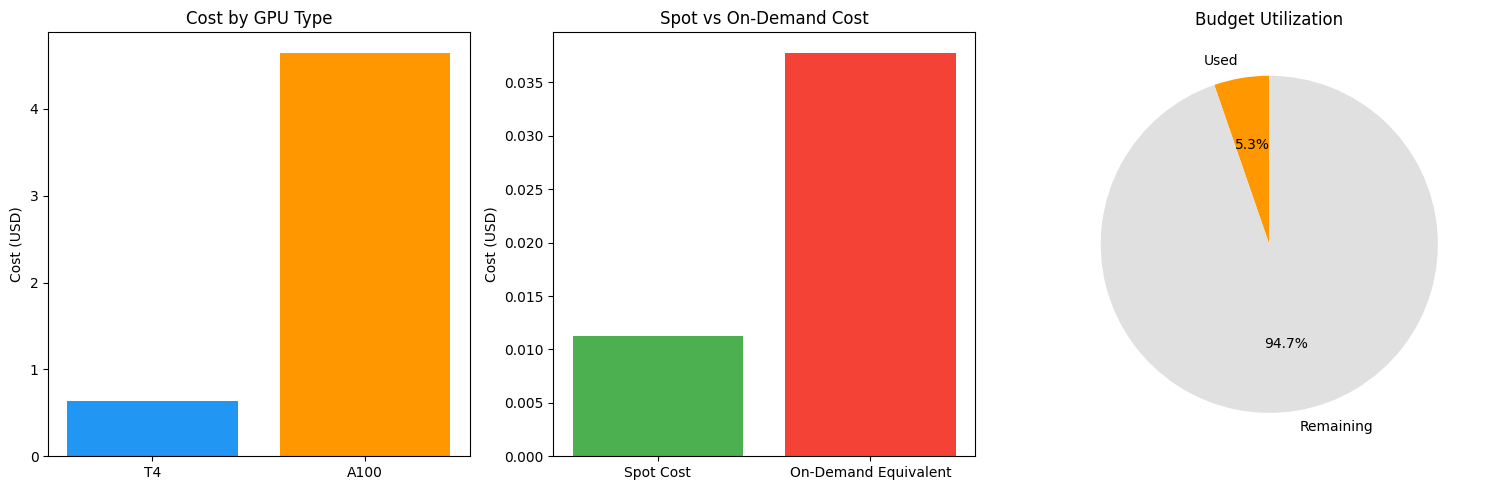

📊 Chart saved as finops_cost_breakdown.png


In [17]:
# Cell 16: Cost Breakdown Visualization
summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1: Cost by GPU type
cost_by_type = summary.get('cost_by_gpu_type', {})
if cost_by_type:
    types = list(cost_by_type.keys())
    costs = [cost_by_type[t]['cost'] for t in types]
    axes[0].bar(types, costs, color=['#2196F3', '#FF9800', '#4CAF50'])
    axes[0].set_title('Cost by GPU Type')
    axes[0].set_ylabel('Cost (USD)')

# Chart 2: Spot vs On-Demand
spot_data = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
labels = ['Spot Cost', 'On-Demand Equivalent']
values = [spot_data.get('total_spot_cost', 0), spot_data.get('on_demand_equivalent', 0)]
axes[1].bar(labels, values, color=['#4CAF50', '#F44336'])
axes[1].set_title('Spot vs On-Demand Cost')
axes[1].set_ylabel('Cost (USD)')

# Chart 3: Budget utilization
budget_used = summary.get('budget_utilization_pct', 0)
axes[2].pie([budget_used, 100-budget_used], labels=['Used', 'Remaining'],
            colors=['#FF9800', '#E0E0E0'], autopct='%1.1f%%', startangle=90)
axes[2].set_title('Budget Utilization')

plt.tight_layout()
plt.savefig('finops_cost_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Chart saved as finops_cost_breakdown.png")

📈 Collecting time-series data (10 snapshots)...


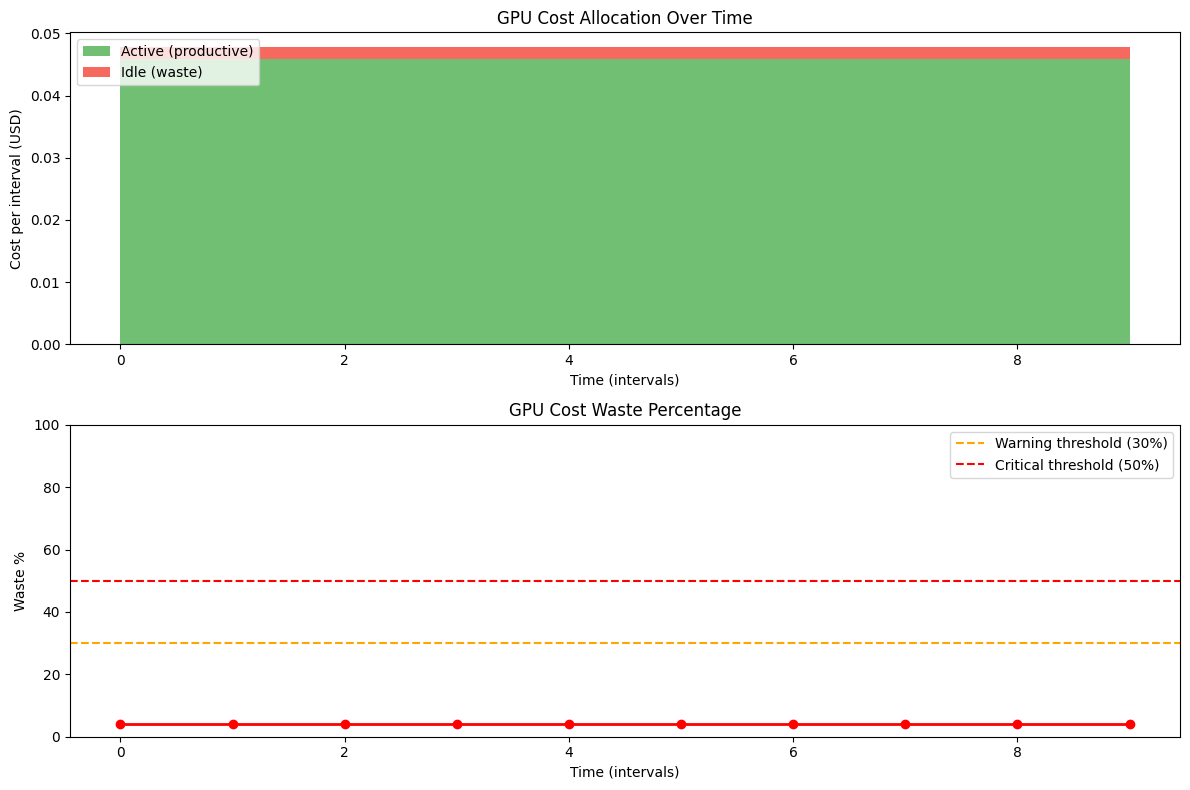

In [18]:
# Cell 17: Time-series cost tracking
print("📈 Collecting time-series data (10 snapshots)...")
ts_data = []
for i in range(10):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    ts_data.append({
        'time': i,
        'total_cost': snap['total_cost_usd'],
        'idle_cost': snap['total_idle_cost_usd'],
        'active_cost': snap['total_active_cost_usd'],
        'waste_pct': snap['waste_pct'],
    })
    time.sleep(1)

df = pd.DataFrame(ts_data)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Cost over time
ax1.stackplot(df['time'], df['active_cost'], df['idle_cost'],
              labels=['Active (productive)', 'Idle (waste)'],
              colors=['#4CAF50', '#F44336'], alpha=0.8)
ax1.set_xlabel('Time (intervals)')
ax1.set_ylabel('Cost per interval (USD)')
ax1.set_title('GPU Cost Allocation Over Time')
ax1.legend(loc='upper left')

# Waste percentage
ax2.plot(df['time'], df['waste_pct'], 'r-o', linewidth=2)
ax2.axhline(y=30, color='orange', linestyle='--', label='Warning threshold (30%)')
ax2.axhline(y=50, color='red', linestyle='--', label='Critical threshold (50%)')
ax2.set_xlabel('Time (intervals)')
ax2.set_ylabel('Waste %')
ax2.set_title('GPU Cost Waste Percentage')
ax2.legend()
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('finops_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 7: Complete FinOps Workflow
Run a full cycle: submit workloads → monitor → detect waste → autoscale → optimize cost.

In [19]:
# Cell 18: Full FinOps Optimization Workflow
print("🔄 FULL FINOPS OPTIMIZATION WORKFLOW")
print("=" * 60)

# Step 1: Check initial state
print("\n1️⃣  Initial cluster state:")
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   GPUs: {m['total_gpus']} | Util: {m['avg_utilization']:.1f}% | Idle: {m['idle_gpus']}")

# Step 2: Submit heavy workloads to increase utilization
print("\n2️⃣  Submitting heavy workloads...")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 600
    })
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   After load: Util: {m['avg_utilization']:.1f}% | Busy: {m['busy_gpus']}/{m['total_gpus']}")

# Step 3: Autoscaler evaluates
print("\n3️⃣  Autoscaler evaluation:")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
print(f"   Decision: {decision['action']} - {decision['reason']}")

# Step 4: Cost snapshot
print("\n4️⃣  Cost analysis:")
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"   Total cost/interval: ${snap['total_cost_usd']:.6f}")
print(f"   Waste: {snap['waste_pct']:.1f}%")

# Step 5: Get recommendations
print("\n5️⃣  Recommendations:")
recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()
for rec in recs:
    print(f"   [{rec['priority']}] {rec['type']}: savings ~{rec['estimated_savings_pct']}%")

# Step 6: Apply optimization - use spot for some workloads
print("\n6️⃣  Applying optimization: Switch to spot instances...")
for i in range(3):
    requests.post(f"{GATEWAY_URL}/spot/request", json={
        "instance_id": f"opt-spot-{i}", "gpu_type": "T4",
        "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": f"heavy-{i:03d}"
    })

savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot savings: ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

# Step 7: Complete workloads and record billing
print("\n7️⃣  Final billing:")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/heavy-{i:03d}/complete")
    requests.post(f"{GATEWAY_URL}/billing/record", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type": "T4",
        "gpu_count": 1, "duration_seconds": 600, "is_spot": i < 3
    })

final = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total spend: ${final['total_cost_usd']:.4f}")
print(f"   Total saved: ${final['total_savings_usd']:.4f}")
print(f"   Budget: {final['budget_utilization_pct']:.1f}% used")
print(f"\n✅ Workflow complete!")

🔄 FULL FINOPS OPTIMIZATION WORKFLOW

1️⃣  Initial cluster state:
   GPUs: 18 | Util: 71.8% | Idle: 2

2️⃣  Submitting heavy workloads...
   After load: Util: 79.9% | Busy: 18/18

3️⃣  Autoscaler evaluation:
   Decision: scale_up - Utilization 79.9% > threshold 70.0%

4️⃣  Cost analysis:
   Total cost/interval: $0.049722
   Waste: 3.9%

5️⃣  Recommendations:
   [MEDIUM] USE_SPOT: savings ~65.0%
   [LOW] SCHEDULING: savings ~20.0%

6️⃣  Applying optimization: Switch to spot instances...
   Spot savings: $0.0357 (70.0%)

7️⃣  Final billing:
   Total spend: $5.4560
   Total saved: $5.6604
   Budget: 5.5% used

✅ Workflow complete!


---
## Part 8: Real GPU Workload on Kaggle/Colab
Train actual models on this notebook's GPU, measure real utilization/time/power, then report cost back to the gateway.

This section:
1. Profiles the **real GPU** available (T4 on Kaggle, T4/V100 on Colab)
2. Trains **ResNet-18 on CIFAR-10** with live GPU monitoring
3. Compares **FP32 vs Mixed Precision (AMP)** to measure time & cost savings
4. Reports all costs back to the FinOps gateway

In [20]:
# Cell 19: Install dependencies & detect real GPU
!pip install -q torch torchvision pynvml

import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
import subprocess
import threading

try:
    from pynvml import (nvmlInit, nvmlDeviceGetHandleByIndex,
                        nvmlDeviceGetUtilizationRates, nvmlDeviceGetMemoryInfo,
                        nvmlDeviceGetPowerUsage, nvmlDeviceGetTemperature)
    PYNVML_AVAILABLE = True
except ImportError:
    PYNVML_AVAILABLE = False
    print("pynvml not available, will use torch.cuda fallback for monitoring")

# Detect GPU
if not torch.cuda.is_available():
    raise RuntimeError("No GPU detected! Enable GPU in Kaggle/Colab settings.")

gpu_name = torch.cuda.get_device_name(0)
gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9

# Map real GPU to pricing
GPU_PRICING = {"T4": 0.35, "A100": 3.67, "V100": 2.48, "P100": 1.46, "L4": 0.81}
detected_type = "T4"  # default
for gtype in GPU_PRICING:
    if gtype.lower() in gpu_name.lower():
        detected_type = gtype
        break

print(f"Real GPU Detected")
print(f"   Name:    {gpu_name}")
print(f"   Memory:  {gpu_mem:.1f} GB")
print(f"   Type:    {detected_type}")
print(f"   Pricing: ${GPU_PRICING[detected_type]:.2f}/hr (on-demand)")
print(f"   CUDA:    {torch.version.cuda}")
print(f"   pynvml:  {'available' if PYNVML_AVAILABLE else 'NOT available'}")

Real GPU Detected
   Name:    Tesla T4
   Memory:  15.6 GB
   Type:    T4
   Pricing: $0.35/hr (on-demand)
   CUDA:    12.8
   pynvml:  available


In [21]:
# Cell 20: GPU Metrics Collection (works on Kaggle/Colab)
# Strategy: pynvml first (reliable Python lib), torch.cuda fallback

def get_gpu_metrics():
    """Get GPU metrics inline. Called during training loop."""

    # Method 1: pynvml (most reliable on Kaggle - pure Python, no subprocess)
    if PYNVML_AVAILABLE:
        try:
            nvmlInit()
            handle = nvmlDeviceGetHandleByIndex(0)
            util = nvmlDeviceGetUtilizationRates(handle)
            mem_info = nvmlDeviceGetMemoryInfo(handle)
            try:
                power = nvmlDeviceGetPowerUsage(handle) / 1000.0  # mW -> W
            except Exception:
                power = 0.0
            try:
                temp = nvmlDeviceGetTemperature(handle, 0)  # NVML_TEMPERATURE_GPU = 0
            except Exception:
                temp = 0.0
            return {
                'timestamp': time.time(),
                'gpu_util_pct': float(util.gpu),
                'mem_util_pct': float(util.memory),
                'mem_used_mb': mem_info.used / 1e6,
                'mem_total_mb': mem_info.total / 1e6,
                'power_watts': float(power),
                'temp_c': float(temp),
            }
        except Exception as e:
            pass  # Fall through to torch.cuda

    # Method 2: torch.cuda (always works, limited metrics)
    mem_used = torch.cuda.memory_allocated() / 1e6
    mem_reserved = torch.cuda.memory_reserved() / 1e6
    mem_total = torch.cuda.get_device_properties(0).total_memory / 1e6
    util_approx = (mem_reserved / mem_total) * 100 if mem_total > 0 else 0
    return {
        'timestamp': time.time(),
        'gpu_util_pct': util_approx,
        'mem_util_pct': util_approx,
        'mem_used_mb': mem_used,
        'mem_total_mb': mem_total,
        'power_watts': 0.0,
        'temp_c': 0.0,
    }

# === DIAGNOSTIC TEST ===
print("=" * 50)
print("GPU METRICS DIAGNOSTIC")
print("=" * 50)

# Test pynvml
print(f"\n1. pynvml available: {PYNVML_AVAILABLE}")
if PYNVML_AVAILABLE:
    try:
        nvmlInit()
        handle = nvmlDeviceGetHandleByIndex(0)
        util = nvmlDeviceGetUtilizationRates(handle)
        mem = nvmlDeviceGetMemoryInfo(handle)
        print(f"   pynvml works! GPU util={util.gpu}%, mem={mem.used/1e6:.0f}/{mem.total/1e6:.0f} MB")
        try:
            pwr = nvmlDeviceGetPowerUsage(handle) / 1000.0
            print(f"   Power: {pwr:.1f}W")
        except Exception as e:
            print(f"   Power: not available ({e})")
        try:
            tmp = nvmlDeviceGetTemperature(handle, 0)
            print(f"   Temp: {tmp}C")
        except Exception as e:
            print(f"   Temp: not available ({e})")
    except Exception as e:
        print(f"   pynvml FAILED: {e}")

# Test full function
print(f"\n2. get_gpu_metrics() test:")
test_result = get_gpu_metrics()
for k, v in sorted(test_result.items()):
    if k != 'timestamp':
        print(f"   {k}: {v}")

print(f"\n   Method: {'pynvml' if test_result.get('temp_c', 0) > 0 or (PYNVML_AVAILABLE and test_result.get('gpu_util_pct', -1) >= 0) else 'torch.cuda'}")
print(f"\nReady for training.")

GPU METRICS DIAGNOSTIC

1. pynvml available: True
   pynvml works! GPU util=0%, mem=472/16106 MB
   Power: 10.3W
   Temp: 42C

2. get_gpu_metrics() test:
   gpu_util_pct: 0.0
   mem_total_mb: 16106.12736
   mem_used_mb: 472.055808
   mem_util_pct: 0.0
   power_watts: 10.312
   temp_c: 42.0

   Method: pynvml

Ready for training.


In [22]:
# Cell 21: Prepare CIFAR-10 dataset and ResNet-18 model
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
]))
testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False, num_workers=2)

print(f"Dataset ready: {len(trainset)} train / {len(testset)} test images")
print(f"Batches per epoch: {len(trainloader)}")


def create_model():
    """Create a fresh ResNet-18 for CIFAR-10."""
    model = torchvision.models.resnet18(weights=None, num_classes=10)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model.cuda()


def train_epoch_monitored(model, loader, optimizer, criterion, use_amp=False, sample_interval=10):
    """Train one epoch with inline GPU metrics collection every N batches."""
    model.train()
    total_loss, correct, total = 0, 0, 0
    scaler = GradScaler() if use_amp else None
    metrics_samples = []
    start = time.time()

    for batch_idx, (inputs, targets) in enumerate(loader):
        inputs, targets = inputs.cuda(), targets.cuda()
        optimizer.zero_grad()

        if use_amp:
            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total += inputs.size(0)

        # Collect GPU metrics every N batches (inline, no threading)
        if batch_idx % sample_interval == 0:
            torch.cuda.synchronize()
            sample = get_gpu_metrics()
            metrics_samples.append(sample)

    elapsed = time.time() - start
    return total_loss / total, correct / total * 100, elapsed, metrics_samples


print("Model & training functions ready (inline monitoring every 10 batches)")

100%|██████████| 170M/170M [00:05<00:00, 32.2MB/s]


Dataset ready: 50000 train / 10000 test images
Batches per epoch: 391
Model & training functions ready (inline monitoring every 10 batches)


In [23]:
# Cell 22: Train FP32 (baseline) with inline GPU monitoring
NUM_EPOCHS = 3
price_per_hour = GPU_PRICING[detected_type]

print("=" * 60)
print("EXPERIMENT 1: FP32 Training (Baseline)")
print("=" * 60)

model_fp32 = create_model()
optimizer_fp32 = optim.SGD(model_fp32.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
fp32_start = time.time()

fp32_results = []
fp32_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_fp32, trainloader, optimizer_fp32, criterion, use_amp=False)
    fp32_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    fp32_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

fp32_total_time = time.time() - fp32_start
fp32_peak_mem = torch.cuda.max_memory_allocated() / 1e9
fp32_cost = (fp32_total_time / 3600) * price_per_hour

print(f"\n   Total samples collected: {len(fp32_all_metrics)}")

# Build monitor dataframe
fp32_monitor_df = pd.DataFrame(fp32_all_metrics)
if not fp32_monitor_df.empty and 'timestamp' in fp32_monitor_df.columns:
    fp32_monitor_df['elapsed'] = fp32_monitor_df['timestamp'] - fp32_monitor_df['timestamp'].iloc[0]

print(f"\n   FP32 Summary:")
print(f"   Total time:      {fp32_total_time:.1f}s")
print(f"   Peak memory:     {fp32_peak_mem:.2f} GB")
if not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns:
    print(f"   Avg GPU util:    {fp32_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {fp32_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {fp32_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {fp32_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(fp32_monitor_df.columns) if not fp32_monitor_df.empty else 'EMPTY'}")
    if fp32_all_metrics:
        print(f"   First sample keys: {list(fp32_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${fp32_cost:.6f}")

EXPERIMENT 1: FP32 Training (Baseline)
   Epoch 1/3 | Loss: 1.9126 | Acc: 32.9% | Time: 44.1s | Samples: 40
   Epoch 2/3 | Loss: 1.3690 | Acc: 49.8% | Time: 41.0s | Samples: 40
   Epoch 3/3 | Loss: 1.0686 | Acc: 61.8% | Time: 44.9s | Samples: 40

   Total samples collected: 120

   FP32 Summary:
   Total time:      130.1s
   Peak memory:     0.82 GB
   Avg GPU util:    91.2%
   Avg power:       66.2W
   Avg temperature: 67.8C
   Max GPU util:    98.0%
   Estimated cost:  $0.012645


In [24]:
# Cell 23: Train Mixed Precision AMP (optimized) with inline GPU monitoring
print("=" * 60)
print("EXPERIMENT 2: Mixed Precision (AMP) Training")
print("=" * 60)

model_amp = create_model()
optimizer_amp = optim.SGD(model_amp.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
amp_start = time.time()

amp_results = []
amp_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_amp, trainloader, optimizer_amp, criterion, use_amp=True)
    amp_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    amp_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

amp_total_time = time.time() - amp_start
amp_peak_mem = torch.cuda.max_memory_allocated() / 1e9
amp_cost = (amp_total_time / 3600) * price_per_hour

print(f"\n   Total samples collected: {len(amp_all_metrics)}")

# Build monitor dataframe
amp_monitor_df = pd.DataFrame(amp_all_metrics)
if not amp_monitor_df.empty and 'timestamp' in amp_monitor_df.columns:
    amp_monitor_df['elapsed'] = amp_monitor_df['timestamp'] - amp_monitor_df['timestamp'].iloc[0]

print(f"\n   AMP Summary:")
print(f"   Total time:      {amp_total_time:.1f}s")
print(f"   Peak memory:     {amp_peak_mem:.2f} GB")
if not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns:
    print(f"   Avg GPU util:    {amp_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {amp_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {amp_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {amp_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(amp_monitor_df.columns) if not amp_monitor_df.empty else 'EMPTY'}")
    if amp_all_metrics:
        print(f"   First sample keys: {list(amp_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${amp_cost:.6f}")

EXPERIMENT 2: Mixed Precision (AMP) Training


/tmp/ipykernel_2189/927799492.py:34: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if use_amp else None
/tmp/ipykernel_2189/927799492.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


   Epoch 1/3 | Loss: 1.9897 | Acc: 29.8% | Time: 24.0s | Samples: 40
   Epoch 2/3 | Loss: 1.4152 | Acc: 47.8% | Time: 23.4s | Samples: 40
   Epoch 3/3 | Loss: 1.1470 | Acc: 58.9% | Time: 24.0s | Samples: 40

   Total samples collected: 120

   AMP Summary:
   Total time:      71.4s
   Peak memory:     0.60 GB
   Avg GPU util:    69.6%
   Avg power:       66.0W
   Avg temperature: 76.6C
   Max GPU util:    87.0%
   Estimated cost:  $0.006940


FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)

Metric                    FP32            AMP             Improvement
----------------------------------------------------------------------
Total Time                130.1           71.4            1.82x faster
Peak Memory (GB)          0.82            0.60            0.22 GB saved
Cost (USD)                $0.012645       $0.006940       $0.005706 saved
Cost Saving %             ---             ---             45.1%
Avg GPU Util %            91.2            69.6           
Avg Power (W)             66.2            66.0           

--- Extrapolated Savings at Scale ---
   1 day training: FP32=$8.40 vs AMP=$4.61 -> SAVE $3.79
   1 week training: FP32=$58.80 vs AMP=$32.27 -> SAVE $26.53
   1 month training: FP32=$252.00 vs AMP=$138.30 -> SAVE $113.70


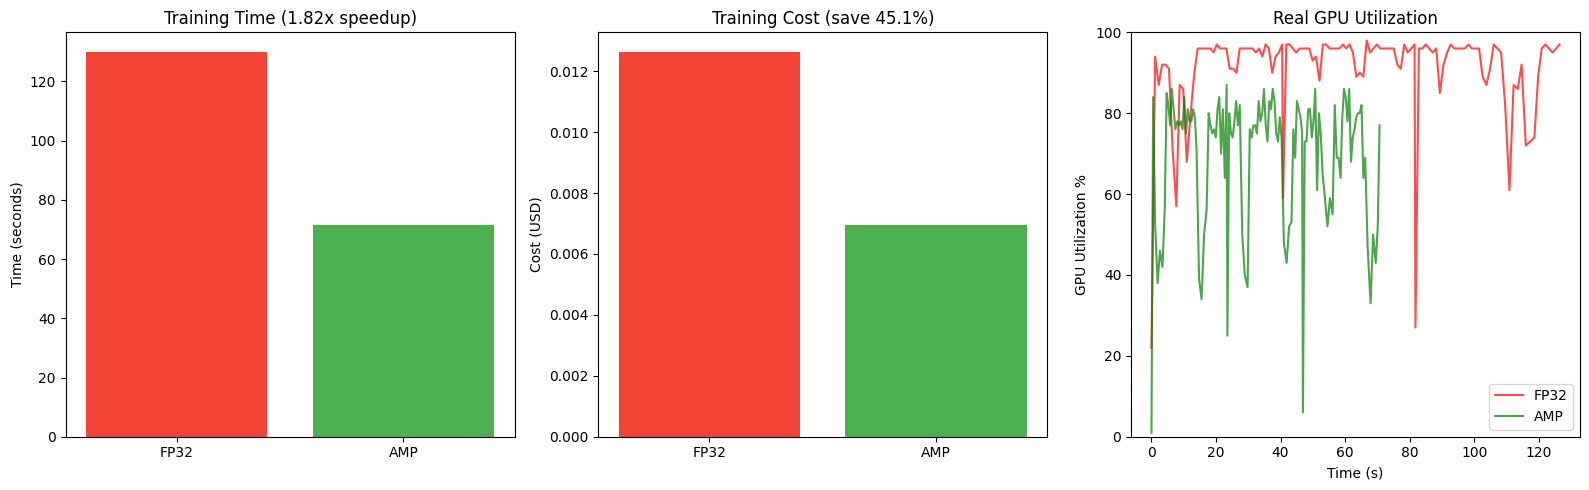

In [25]:
# Cell 24: Compare FP32 vs AMP - FinOps Analysis
print("=" * 60)
print("FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)")
print("=" * 60)

speedup = fp32_total_time / amp_total_time
cost_saving = fp32_cost - amp_cost
cost_saving_pct = (cost_saving / fp32_cost) * 100 if fp32_cost > 0 else 0
mem_saving = fp32_peak_mem - amp_peak_mem

print(f"\n{'Metric':<25} {'FP32':<15} {'AMP':<15} {'Improvement'}")
print("-" * 70)
print(f"{'Total Time':<25} {fp32_total_time:<15.1f} {amp_total_time:<15.1f} {speedup:.2f}x faster")
print(f"{'Peak Memory (GB)':<25} {fp32_peak_mem:<15.2f} {amp_peak_mem:<15.2f} {mem_saving:.2f} GB saved")
print(f"{'Cost (USD)':<25} ${fp32_cost:<14.6f} ${amp_cost:<14.6f} ${cost_saving:.6f} saved")
print(f"{'Cost Saving %':<25} {'---':<15} {'---':<15} {cost_saving_pct:.1f}%")

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    print(f"{'Avg GPU Util %':<25} {fp32_monitor_df['gpu_util_pct'].mean():<15.1f} {amp_monitor_df['gpu_util_pct'].mean():<15.1f}")
    print(f"{'Avg Power (W)':<25} {fp32_monitor_df['power_watts'].mean():<15.1f} {amp_monitor_df['power_watts'].mean():<15.1f}")

# Extrapolate to larger scale
print(f"\n--- Extrapolated Savings at Scale ---")
for scale_name, hours in [("1 day training", 24), ("1 week training", 168), ("1 month training", 720)]:
    fp32_scaled = hours * price_per_hour
    amp_scaled = (hours / speedup) * price_per_hour
    saved = fp32_scaled - amp_scaled
    print(f"   {scale_name}: FP32=${fp32_scaled:.2f} vs AMP=${amp_scaled:.2f} -> SAVE ${saved:.2f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bar: Time comparison
axes[0].bar(['FP32', 'AMP'], [fp32_total_time, amp_total_time], color=['#F44336', '#4CAF50'])
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title(f'Training Time ({speedup:.2f}x speedup)')

# Bar: Cost comparison
axes[1].bar(['FP32', 'AMP'], [fp32_cost, amp_cost], color=['#F44336', '#4CAF50'])
axes[1].set_ylabel('Cost (USD)')
axes[1].set_title(f'Training Cost (save {cost_saving_pct:.1f}%)')

# Line: GPU utilization over time (both experiments) or epoch time
if has_monitor_data:
    if not fp32_monitor_df.empty:
        axes[2].plot(fp32_monitor_df['elapsed'], fp32_monitor_df['gpu_util_pct'], 'r-', alpha=0.7, label='FP32')
    if not amp_monitor_df.empty:
        axes[2].plot(amp_monitor_df['elapsed'], amp_monitor_df['gpu_util_pct'], 'g-', alpha=0.7, label='AMP')
    axes[2].set_xlabel('Time (s)')
    axes[2].set_ylabel('GPU Utilization %')
    axes[2].set_title('Real GPU Utilization')
    axes[2].legend()
    axes[2].set_ylim(0, 100)
else:
    # Fallback: show epoch times
    epochs = list(range(1, NUM_EPOCHS + 1))
    axes[2].plot(epochs, [r['time_s'] for r in fp32_results], 'r-o', label='FP32')
    axes[2].plot(epochs, [r['time_s'] for r in amp_results], 'g-o', label='AMP')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Time (s)')
    axes[2].set_title('Time per Epoch')
    axes[2].legend()

plt.tight_layout()
plt.savefig('real_gpu_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# Cell 25: Report real GPU costs back to the FinOps Gateway
print("=" * 60)
print("REPORTING REAL GPU COSTS TO FINOPS GATEWAY")
print("=" * 60)

# Report FP32 workload
fp32_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-fp32",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": fp32_total_time,
    "is_spot": False,
    "project": "real-gpu-lab",
}).json()
print(f"\n   FP32 workload reported:")
print(f"   Cost: ${fp32_report['total_cost_usd']:.6f} | Rate: ${fp32_report['rate_per_hour']:.4f}/hr")

# Report AMP workload (as spot - demonstrating cost optimization)
amp_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-amp",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": amp_total_time,
    "is_spot": True,
    "project": "real-gpu-lab",
}).json()
print(f"\n   AMP workload reported (as spot):")
print(f"   Cost: ${amp_report['total_cost_usd']:.6f} | Saved: ${amp_report['savings_usd']:.6f}")

# Submit workload info to cluster tracker
for wl_name, wl_time in [("real-gpu-resnet18-fp32", fp32_total_time), ("real-gpu-resnet18-amp", amp_total_time)]:
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": wl_name,
        "gpu_type_preferred": detected_type,
        "gpu_count": 1,
        "duration_seconds": int(wl_time),
    })

# Get updated billing summary including real GPU data
print(f"\n--- Updated FinOps Billing (incl. real GPU) ---")
summary = requests.get(f"{GATEWAY_URL}/billing/summary", params={"project": "real-gpu-lab"}).json()
print(f"   Project:         real-gpu-lab")
print(f"   Total Cost:      ${summary['total_cost_usd']:.6f}")
print(f"   Total Savings:   ${summary['total_savings_usd']:.6f}")
print(f"   Workloads:       {summary['total_workloads']}")

# Push real GPU metrics as a cost snapshot
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"\n   Cost snapshot taken: waste={snap['waste_pct']:.1f}%")

# Get final dashboard with everything
print(f"\n--- FINAL DASHBOARD (Mock + Real GPU) ---")
dash = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()
bs = dash.get('billing_summary', {})
print(f"   Total Platform Cost:  ${bs.get('total_cost_usd', 0):.4f}")
print(f"   Total Savings:        ${bs.get('total_savings_usd', 0):.4f}")
print(f"   Budget Utilization:   {bs.get('budget_utilization_pct', 0):.1f}%")
print(f"   Alert:                {bs.get('alert', 'N/A')}")

REPORTING REAL GPU COSTS TO FINOPS GATEWAY

   FP32 workload reported:
   Cost: $0.012600 | Rate: $0.3500/hr

   AMP workload reported (as spot):
   Cost: $0.002100 | Saved: $0.004900

--- Updated FinOps Billing (incl. real GPU) ---
   Project:         real-gpu-lab
   Total Cost:      $0.014700
   Total Savings:   $0.004900
   Workloads:       2

   Cost snapshot taken: waste=17.8%

--- FINAL DASHBOARD (Mock + Real GPU) ---
   Total Platform Cost:  $5.4560
   Total Savings:        $5.6604
   Budget Utilization:   5.5%
   Alert:                OK


Real GPU Telemetry During Training


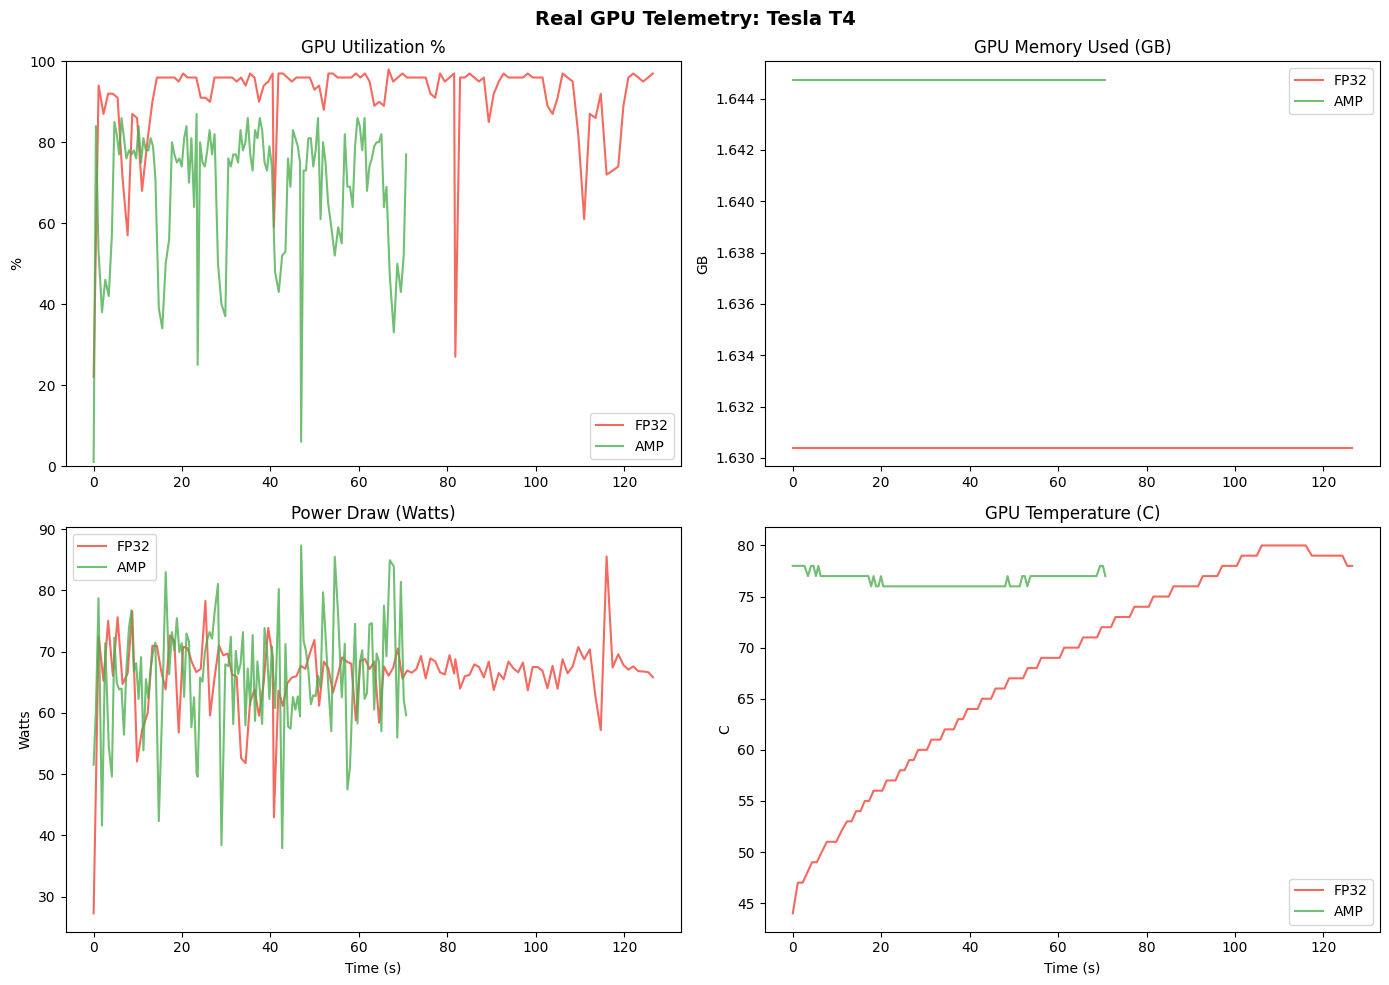

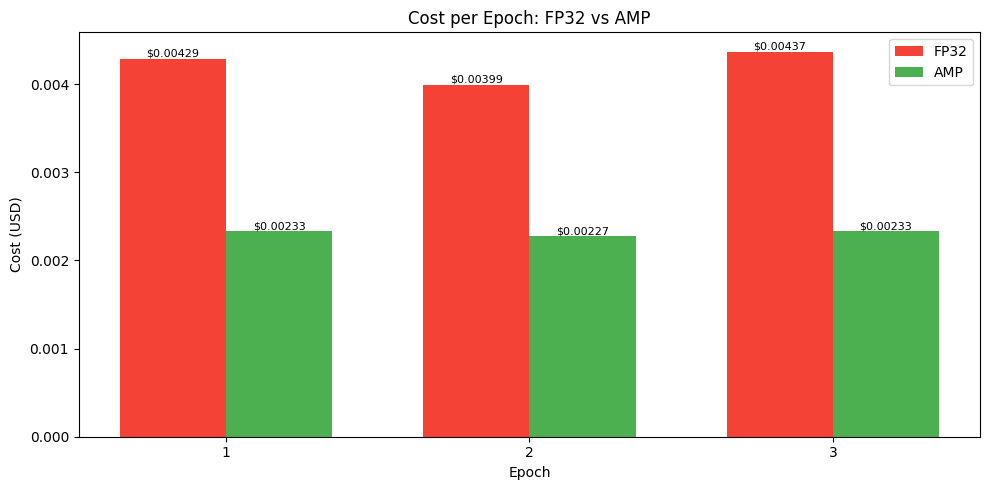


Charts saved: cost_per_epoch.png, real_gpu_telemetry.png


In [27]:
# Cell 26: Real GPU Monitoring Visualization
print("Real GPU Telemetry During Training")
print("=" * 60)

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # GPU Utilization
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 0].plot(df['elapsed'], df['gpu_util_pct'], color=color, alpha=0.8, label=label)
    axes[0, 0].set_title('GPU Utilization %')
    axes[0, 0].set_ylabel('%')
    axes[0, 0].legend()
    axes[0, 0].set_ylim(0, 100)

    # Memory Usage
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 1].plot(df['elapsed'], df['mem_used_mb'] / 1024, color=color, alpha=0.8, label=label)
    axes[0, 1].set_title('GPU Memory Used (GB)')
    axes[0, 1].set_ylabel('GB')
    axes[0, 1].legend()

    # Power Draw
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 0].plot(df['elapsed'], df['power_watts'], color=color, alpha=0.8, label=label)
    axes[1, 0].set_title('Power Draw (Watts)')
    axes[1, 0].set_ylabel('Watts')
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].legend()

    # Temperature
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 1].plot(df['elapsed'], df['temp_c'], color=color, alpha=0.8, label=label)
    axes[1, 1].set_title('GPU Temperature (C)')
    axes[1, 1].set_ylabel('C')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].legend()

    plt.suptitle(f'Real GPU Telemetry: {gpu_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('real_gpu_telemetry.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("   GPU telemetry not available (monitor collected 0 samples).")
    print("   Showing epoch-level metrics instead.\n")

# Cost per epoch chart (always works)
fig, ax = plt.subplots(figsize=(10, 5))
fp32_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in fp32_results]
amp_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in amp_results]
epochs = list(range(1, NUM_EPOCHS + 1))

x = range(len(epochs))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], fp32_epoch_costs, width, label='FP32', color='#F44336')
bars2 = ax.bar([i + width/2 for i in x], amp_epoch_costs, width, label='AMP', color='#4CAF50')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cost (USD)')
ax.set_title('Cost per Epoch: FP32 vs AMP')
ax.set_xticks(x)
ax.set_xticklabels(epochs)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('cost_per_epoch.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCharts saved: cost_per_epoch.png" + (", real_gpu_telemetry.png" if has_monitor_data else ""))

---
## Part 8.5: Advanced GPU Cost Optimization
Apply advanced FinOps techniques: multi-GPU cost analysis, project forecasting, and optimization strategy prioritization.

This section extends Part 8 with:
1. **Multi-GPU Cost Analysis** - Compare scaling efficiency and determine optimal GPU count
2. **Project Cost Forecasting** - Forecast multi-phase project costs with confidence intervals
3. **Optimization Opportunity Analysis** - Prioritize and combine optimization strategies

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

print("=" * 60)
print("EXERCISE 8.5.1: Multi-GPU Cost Analysis")
print("=" * 60)

GPU_PRICING = {"T4": 0.35, "A100": 3.67, "V100": 2.48, "P100": 1.46, "L4": 0.81}

def analyze_multi_gpu_cost(base_time_hours, gpu_type, gpu_counts, scaling_factors=None):
    """
    Analyze costs for different GPU counts with realistic scaling.
    Uses Amdahl's law-inspired sub-linear scaling for efficiency.
    """
    price = GPU_PRICING.get(gpu_type, 3.67)

    if scaling_factors is None:
        # Realistic scaling: 2 GPUs = 1.8x, 4 = 3.4x, 8 = 6.5x (not linear)
        scaling_factors = {1: 1.0, 2: 1.8, 4: 3.4, 8: 6.5}

    results = []
    for n in gpu_counts:
        sf = scaling_factors.get(n, n ** 0.85)
        scaled_time = base_time_hours / sf
        total_cost = scaled_time * price * n
        cost_per_unit = total_cost / sf  # cost per "effective" GPU-hour
        efficiency = sf / n * 100  # parallel efficiency %

        results.append({
            'gpu_count': n,
            'time_hours': scaled_time,
            'total_cost': total_cost,
            'cost_per_gpu_hour': price * n,
            'scaling_factor': sf,
            'parallel_efficiency': efficiency,
            'cost_per_perf_unit': cost_per_unit,
        })

    df = pd.DataFrame(results)

    # Find optimal (lowest total cost)
    idx_optimal = df['total_cost'].idxmin()

    return {'table': df, 'optimal_gpu_count': df.loc[idx_optimal, 'gpu_count'],
            'optimal_time': df.loc[idx_optimal, 'time_hours'],
            'optimal_cost': df.loc[idx_optimal, 'total_cost']}

# Test
base_training_time = 2.0
test_gpu_counts = [1, 2, 4, 8]
result = analyze_multi_gpu_cost(base_training_time, "A100", test_gpu_counts)
df = result['table']

print(f"\n{'GPU#':<8}{'Time(h)':<10}{'Total Cost':<14}{'$/GPU/hr':<12}{'Speedup':<10}{'Efficiency%':<12}{'Optimal?'}")
print("-" * 78)
for _, row in df.iterrows():
    optimal = " <-- OPTIMAL" if row['gpu_count'] == result['optimal_gpu_count'] else ""
    print(f"{int(row['gpu_count']):<8}{row['time_hours']:<10.2f}${row['total_cost']:<13.2f}${row['cost_per_gpu_hour']:<11.2f}"
          f"{row['scaling_factor']:<10.1f}x{row['parallel_efficiency']:<11.1f}{optimal}")

print(f"\n>>> Optimal configuration: {int(result['optimal_gpu_count'])} GPUs")
print(f"    Time: {result['optimal_time']:.2f}h | Cost: ${result['optimal_cost']:.2f}")

EXERCISE 8.5.1: Multi-GPU Cost Analysis

GPU#    Time(h)   Total Cost    $/GPU/hr    Speedup   Efficiency% Optimal?
------------------------------------------------------------------------------
1       2.00      $7.34         $3.67       1.0       x100.0       <-- OPTIMAL
2       1.11      $8.16         $7.34       1.8       x90.0       
4       0.59      $8.64         $14.68      3.4       x85.0       
8       0.31      $9.03         $29.36      6.5       x81.2       

>>> Optimal configuration: 1 GPUs
    Time: 2.00h | Cost: $7.34


In [34]:
print("=" * 60)
print("EXERCISE 8.5.2: Project Cost Forecasting")
print("=" * 60)

def forecast_project_cost(phases, contingency_pct=20, confidence_level=0.95):
    """
    Forecast multi-phase project costs with confidence intervals.
    Uses log-normal distribution for cost uncertainty.
    """
    phase_details = []
    total_base = 0

    print(f"\n{'Phase':<25}{'GPU':<8}{'#GPU':<6}{'Hours':<8}{'Base Cost':<12}{'Uncertainty'}")
    print("-" * 75)

    for p in phases:
        price = GPU_PRICING.get(p['gpu_type'], 3.67)
        base = price * p['gpu_count'] * p['duration_hours']
        total_base += base

        # Log-normal uncertainty model
        sigma = p['uncertainty_pct']
        z = stats.norm.ppf(confidence_level)
        lower = base * np.exp(-z * sigma)
        upper = base * np.exp(z * sigma)

        phase_details.append({
            'name': p['name'],
            'gpu_type': p['gpu_type'],
            'gpu_count': p['gpu_count'],
            'duration_hours': p['duration_hours'],
            'base_cost': base,
            'lower': lower,
            'upper': upper,
            'uncertainty_pct': p['uncertainty_pct'],
        })
        print(f"{p['name']:<25}{p['gpu_type']:<8}{p['gpu_count']:<6}{p['duration_hours']:<8}"
              f"${base:<11.2f} +/-{p['uncertainty_pct']*100:.0f}%")

    # Confidence interval for total
    combined_sigma = np.sqrt(sum(p['uncertainty_pct']**2 for p in phases))
    z = stats.norm.ppf(confidence_level)
    contingency = total_base * (contingency_pct / 100)

    total_lower = total_base * np.exp(-z * combined_sigma)
    total_upper = total_base * np.exp(z * combined_sigma)
    expected = total_base + contingency

    print(f"\n{'='*50}")
    print(f"  Base cost:         ${total_base:.2f}")
    print(f"  Contingency ({contingency_pct}%):   +${contingency:.2f}")
    print(f"  Expected total:    ${expected:.2f}")
    print(f"  {confidence_level*100:.0f}% CI:        ${total_lower+contingency:.2f} - ${total_upper+contingency:.2f}")
    print(f"  Best case:         ${total_lower:.2f}")
    print(f"  Worst case:        ${total_upper+contingency*2:.2f}")

    return {
        'base_cost': total_base,
        'contingency': contingency,
        'expected_total': expected,
        'ci_lower': total_lower + contingency,
        'ci_upper': total_upper + contingency,
        'phases': phase_details,
    }

# Example project
example_project = [
    {"name": "Data Preparation",    "gpu_type": "T4",   "gpu_count": 1,  "duration_hours": 40,  "uncertainty_pct": 0.15},
    {"name": "Model Training",      "gpu_type": "A100", "gpu_count": 4,  "duration_hours": 120, "uncertainty_pct": 0.25},
    {"name": "Hyperparameter Tuning","gpu_type": "A100", "gpu_count": 8,  "duration_hours": 60,  "uncertainty_pct": 0.30},
    {"name": "Model Evaluation",     "gpu_type": "T4",   "gpu_count": 2,  "duration_hours": 20,  "uncertainty_pct": 0.10},
]

forecast = forecast_project_cost(example_project)

EXERCISE 8.5.2: Project Cost Forecasting

Phase                    GPU     #GPU  Hours   Base Cost   Uncertainty
---------------------------------------------------------------------------
Data Preparation         T4      1     40      $14.00       +/-15%
Model Training           A100    4     120     $1761.60     +/-25%
Hyperparameter Tuning    A100    8     60      $1761.60     +/-30%
Model Evaluation         T4      2     20      $14.00       +/-10%

  Base cost:         $3551.20
  Contingency (20%):   +$710.24
  Expected total:    $4261.44
  95% CI:        $2460.58 - $7915.16
  Best case:         $1750.34
  Worst case:        $8625.40


In [35]:
print("=" * 60)
print("EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis")
print("=" * 60)

def analyze_optimization_opportunities(current_config, optimization_strategies):
    """
    Prioritize optimization strategies by savings/effort ratio,
    considering risk and dependencies.
    """
    effort_map = {"LOW": 1, "MEDIUM": 2, "HIGH": 3}

    # Calculate priority score: (savings * (4 - risk_score)) / effort
    # Higher score = higher priority
    for s in optimization_strategies:
        risk_score = effort_map.get(s['risk_level'], 2)
        effort_score = effort_map.get(s['implementation_effort'], 2)
        s['priority_score'] = (s['savings_pct'] * (5 - risk_score)) / effort_score

    # Sort by priority score descending
    sorted_strategies = sorted(optimization_strategies, key=lambda x: x['priority_score'], reverse=True)

    # Calculate cumulative savings
    cumulative = 1.0
    print(f"\n{'Rank':<6}{'Strategy':<35}{'Savings':<10}{'Effort':<10}{'Risk':<8}{'Score':<8}{'Cumul.Savings'}")
    print("-" * 95)
    for i, s in enumerate(sorted_strategies, 1):
        cumulative *= (1 - s['savings_pct'])
        total_savings = (1 - cumulative) * 100
        print(f"{i:<6}{s['name']:<35}{s['savings_pct']*100:<9.0f}%{s['implementation_effort']:<10}{s['risk_level']:<8}"
              f"{s['priority_score']:<8.2f}{total_savings:.1f}%")

    total_savings_pct = (1 - cumulative) * 100

    # Quick wins (LOW effort, LOW risk)
    quick_wins = [s['name'] for s in sorted_strategies
                  if s['implementation_effort'] == 'LOW' and s['risk_level'] == 'LOW']

    # High impact (HIGH savings)
    high_impact = [s['name'] for s in sorted_strategies if s['savings_pct'] >= 0.20]

    print(f"\n>>> Total potential savings: {total_savings_pct:.1f}%")
    print(f">>> Quick wins (implement first): {', '.join(quick_wins)}")
    print(f">>> High impact strategies: {', '.join(high_impact)}")

    return {'ranked': sorted_strategies, 'total_savings_pct': total_savings_pct,
            'quick_wins': quick_wins, 'high_impact': high_impact}

# Example
example_strategies = [
    {"name": "Switch to Mixed Precision (AMP)",  "savings_pct": 0.25, "implementation_effort": "LOW",   "risk_level": "LOW",   "dependencies": []},
    {"name": "Use Spot Instances",               "savings_pct": 0.60, "implementation_effort": "MEDIUM","risk_level": "HIGH",  "dependencies": []},
    {"name": "Optimize Batch Size",              "savings_pct": 0.15, "implementation_effort": "LOW",   "risk_level": "LOW",   "dependencies": []},
    {"name": "Implement Early Stopping",         "savings_pct": 0.20, "implementation_effort": "MEDIUM","risk_level": "LOW",   "dependencies": []},
    {"name": "Switch to More Efficient GPU",     "savings_pct": 0.40, "implementation_effort": "HIGH",  "risk_level": "MEDIUM","dependencies": []},
]

current_config = {
    "gpu_type": "A100", "gpu_count": 4, "duration_hours": 100,
    "precision": "FP32", "instance_type": "on-demand",
}

opt_result = analyze_optimization_opportunities(current_config, example_strategies.copy())

EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis

Rank  Strategy                           Savings   Effort    Risk    Score   Cumul.Savings
-----------------------------------------------------------------------------------------------
1     Switch to Mixed Precision (AMP)    25       %LOW       LOW     1.00    25.0%
2     Use Spot Instances                 60       %MEDIUM    HIGH    0.60    70.0%
3     Optimize Batch Size                15       %LOW       LOW     0.60    74.5%
4     Switch to More Efficient GPU       40       %HIGH      MEDIUM  0.40    84.7%
5     Implement Early Stopping           20       %MEDIUM    LOW     0.40    87.8%

>>> Total potential savings: 87.8%
>>> Quick wins (implement first): Switch to Mixed Precision (AMP), Optimize Batch Size
>>> High impact strategies: Switch to Mixed Precision (AMP), Use Spot Instances, Switch to More Efficient GPU, Implement Early Stopping


EXERCISE 8.5.4: Integrated Cost Dashboard


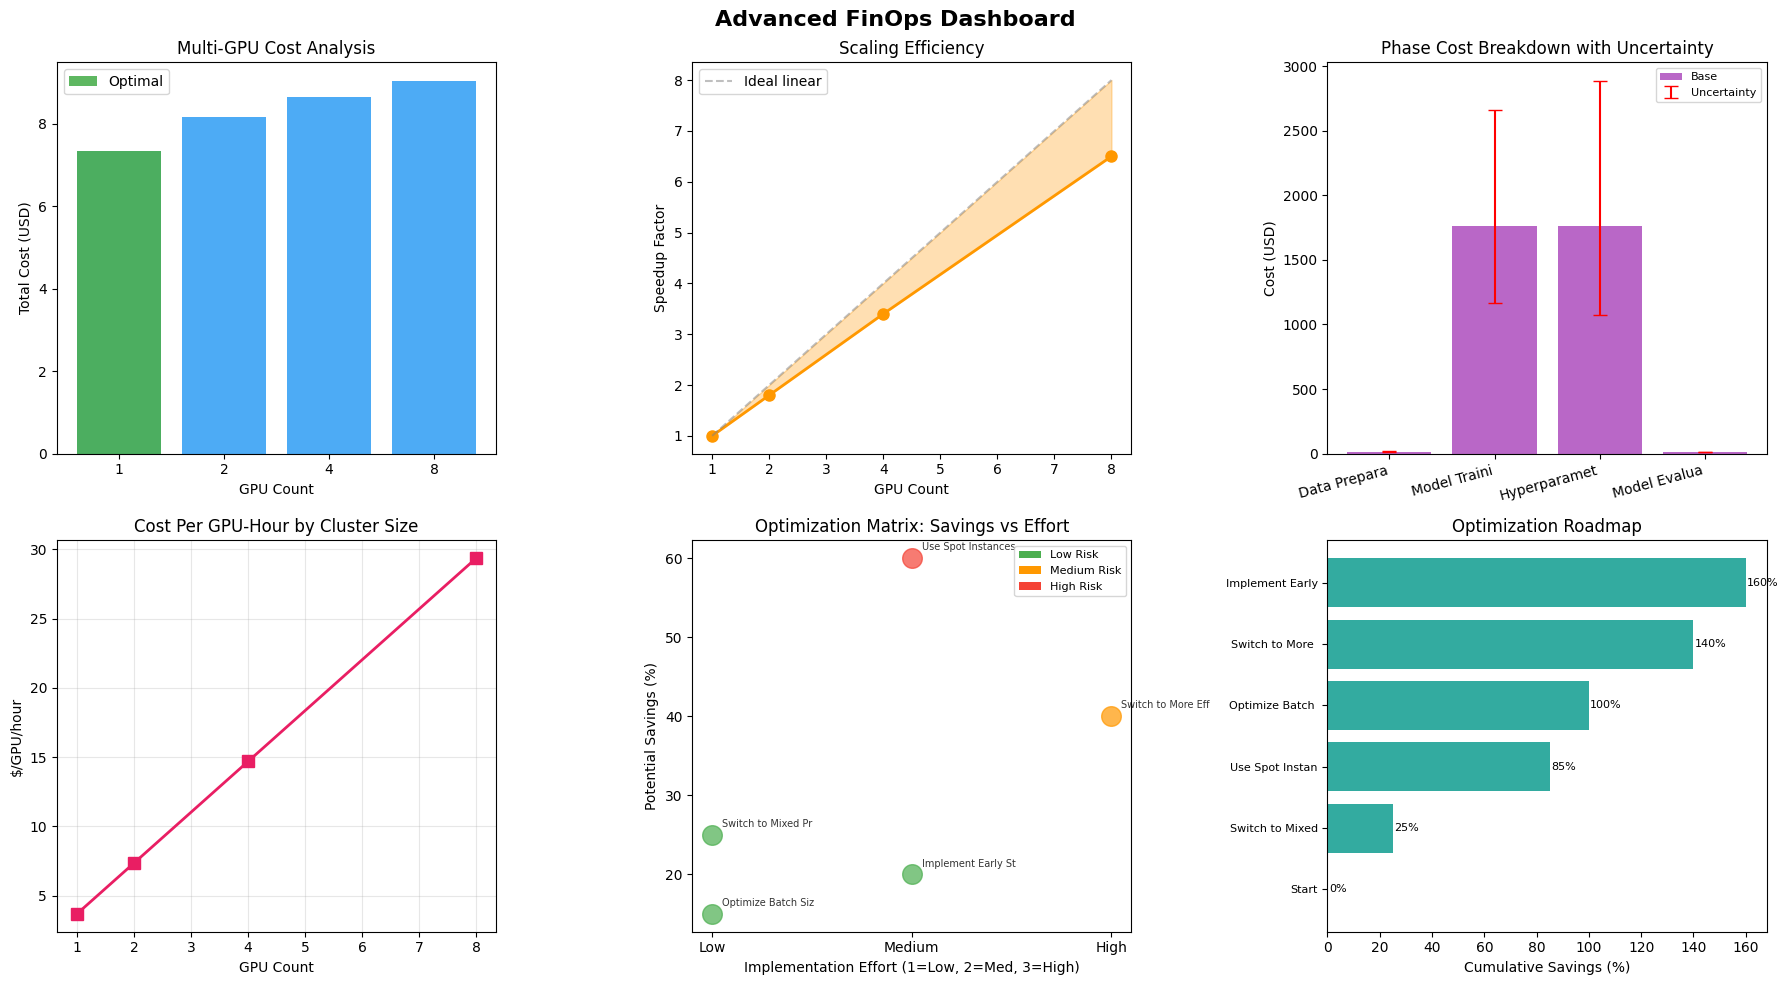

Dashboard saved as advanced_finops_dashboard.png


In [36]:
print("=" * 60)
print("EXERCISE 8.5.4: Integrated Cost Dashboard")
print("=" * 60)

def create_advanced_finops_dashboard(multi_gpu_analysis, project_forecast, optimization_recommendations):
    """
    Create 6-panel integrated dashboard.
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # 1. Multi-GPU Cost Curve
    df = multi_gpu_analysis['table']
    ax = axes[0, 0]
    bars = ax.bar(df['gpu_count'].astype(str), df['total_cost'], color='#2196F3', alpha=0.8)
    ax.bar(df[df['gpu_count'] == multi_gpu_analysis['optimal_gpu_count']]['gpu_count'].astype(str),
           df[df['gpu_count'] == multi_gpu_analysis['optimal_gpu_count']]['total_cost'],
           color='#4CAF50', alpha=0.9, label='Optimal')
    ax.set_xlabel('GPU Count')
    ax.set_ylabel('Total Cost (USD)')
    ax.set_title('Multi-GPU Cost Analysis')
    ax.legend()

    # 2. Scaling Efficiency
    ax = axes[0, 1]
    ax.plot(df['gpu_count'], df['scaling_factor'], 'o-', color='#FF9800', linewidth=2, markersize=8)
    ax.plot(df['gpu_count'], df['gpu_count'], '--', color='gray', alpha=0.5, label='Ideal linear')
    ax.fill_between(df['gpu_count'], df['scaling_factor'], df['gpu_count'], alpha=0.3, color='#FF9800')
    ax.set_xlabel('GPU Count')
    ax.set_ylabel('Speedup Factor')
    ax.set_title('Scaling Efficiency')
    ax.legend()

    # 3. Project Forecast CI
    ax = axes[0, 2]
    phases = project_forecast['phases']
    names = [p['name'][:12] for p in phases]
    costs = [p['base_cost'] for p in phases]
    lowers = [p['base_cost'] - p['lower'] for p in phases]
    uppers = [p['upper'] - p['base_cost'] for p in phases]
    x = range(len(phases))
    ax.bar(x, costs, color='#9C27B0', alpha=0.7, label='Base')
    ax.errorbar(x, costs, yerr=[lowers, uppers], fmt='none', color='red', capsize=5, label='Uncertainty')
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=15, ha='right')
    ax.set_ylabel('Cost (USD)')
    ax.set_title('Phase Cost Breakdown with Uncertainty')
    ax.legend(fontsize=8)

    # 4. Cost per GPU-hour across GPU counts
    ax = axes[1, 0]
    ax.plot(df['gpu_count'], df['cost_per_gpu_hour'], 's-', color='#E91E63', linewidth=2, markersize=8)
    ax.set_xlabel('GPU Count')
    ax.set_ylabel('$/GPU/hour')
    ax.set_title('Cost Per GPU-Hour by Cluster Size')
    ax.grid(True, alpha=0.3)

    # 5. Optimization: Savings vs Effort scatter
    ax = axes[1, 1]
    ranked = optimization_recommendations['ranked']
    effort_map = {"LOW": 1, "MEDIUM": 2, "HIGH": 3}
    risk_map = {"LOW": 1, "MEDIUM": 2, "HIGH": 3}
    colors = {'LOW': '#4CAF50', 'MEDIUM': '#FF9800', 'HIGH': '#F44336'}

    for s in ranked:
        ax.scatter(effort_map[s['implementation_effort']], s['savings_pct']*100,
                   c=colors[s['risk_level']], s=200, alpha=0.7)
        ax.annotate(s['name'][:18], (effort_map[s['implementation_effort']]+0.05, s['savings_pct']*100+1),
                    fontsize=7, alpha=0.8)
    ax.set_xlabel('Implementation Effort (1=Low, 2=Med, 3=High)')
    ax.set_ylabel('Potential Savings (%)')
    ax.set_title('Optimization Matrix: Savings vs Effort')
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=colors['LOW'], label='Low Risk'),
                       Patch(facecolor=colors['MEDIUM'], label='Medium Risk'),
                       Patch(facecolor=colors['HIGH'], label='High Risk')]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=8)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(['Low', 'Medium', 'High'])

    # 6. Cumulative Savings Roadmap
    ax = axes[1, 2]
    ranked = optimization_recommendations['ranked']
    cumulative = [0]
    labels = ['Start']
    current = 0
    for s in ranked:
        current += s['savings_pct'] * 100
        cumulative.append(current)
        labels.append(s['name'][:15])

    ax.barh(range(len(cumulative)), cumulative, color='#009688', alpha=0.8)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel('Cumulative Savings (%)')
    ax.set_title('Optimization Roadmap')
    for i, v in enumerate(cumulative):
        ax.text(v + 0.5, i, f'{v:.0f}%', va='center', fontsize=8)

    plt.suptitle('Advanced FinOps Dashboard', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('advanced_finops_dashboard.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Dashboard saved as advanced_finops_dashboard.png")
    return fig

# Run with existing data
dashboard = create_advanced_finops_dashboard(result, forecast, opt_result)

In [38]:
print("=" * 60)
print("CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy")
print("=" * 60)

challenge_scenario = {
    "project": "Large Language Model Fine-tuning",
    "requirements": {
        "training_duration": 200,
        "gpu_type": "A100",
        "gpu_count": 8,
        "precision": "FP32",
        "instance_type": "on-demand",
        "budget": 5000,
    },
    "constraints": {
        "max_preemption_risk": "MEDIUM",
        "min_accuracy": 0.95,
        "deadline": "2 weeks",
    }
}

print("CHALLENGE SCENARIO:")
print(f"   Project: {challenge_scenario['project']}")
print(f"   Baseline: {challenge_scenario['requirements']['gpu_count']}x "
      f"{challenge_scenario['requirements']['gpu_type']} for "
      f"{challenge_scenario['requirements']['training_duration']}h")
print(f"   Budget: ${challenge_scenario['requirements']['budget']}") # Fixed KeyError path
print(f"   Deadline: {challenge_scenario['constraints']['deadline']}")

# ================================================================
# STEP 1: Calculate baseline cost
# ================================================================
print("\n" + "="*60)
print("STEP 1: Baseline Cost")
print("="*60)

gpu_type = challenge_scenario['requirements']['gpu_type']
gpu_count = challenge_scenario['requirements']['gpu_count']
duration = challenge_scenario['requirements']['training_duration']
budget = challenge_scenario['requirements']['budget'] # Fixed KeyError path
price = GPU_PRICING[gpu_type]

baseline_cost = duration * price * gpu_count
print(f"   {gpu_count}x {gpu_type} @ ${price}/hr for {duration}h")
print(f"   Baseline cost: ${baseline_cost:.2f}")
print(f"   Budget:         ${budget:.2f}")
print(f"   Over budget by: ${baseline_cost - budget:.2f} -> NEEDS OPTIMIZATION!")

# ================================================================
# STEP 2: Multi-GPU analysis
# ================================================================
print("\n" + "="*60)
print("STEP 2: Multi-GPU Analysis")
print("="*60)

gpu_counts = [1, 2, 4, 8, 16]
multi_result = analyze_multi_gpu_cost(duration, gpu_type, gpu_counts)
multi_df = multi_result['table']

print(f"\n{'GPU#':<8}{'Time(h)':<10}{'Total Cost':<14}{'Efficiency%':<12}")
print("-" * 50)
for _, row in multi_df.iterrows():
    print(f"{int(row['gpu_count']):<8}{row['time_hours']:<10.1f}${row['total_cost']:<13.2f}{row['parallel_efficiency']:<11.1f}")

optimal_gpus = int(multi_result['optimal_gpu_count'])
optimal_time = multi_result['optimal_time']
optimal_cost = multi_result['optimal_cost']
print(f"\n   Optimal GPU count: {optimal_gpus} (cost: ${optimal_cost:.2f})")
print(f"   Deadline check: {optimal_time:.1f}h needed -> {336/optimal_time:.1f}x faster than single GPU")
print(f"   Within 2 weeks ({336}h): {'YES' if optimal_time <= 336 else 'NO'}")

# ================================================================
# STEP 3: Optimization strategies selection
# ================================================================
print("\n" + "="*60)
print("STEP 3: Optimization Strategies")
print("="*60)

# Selected strategies for this project
strategies = [
    # Quick wins (LOW effort, LOW risk)
    {"name": "Mixed Precision (AMP)",           "savings_pct": 0.25, "implementation_effort": "LOW",   "risk_level": "LOW",   "dependencies": []},
    {"name": "Early Stopping",                  "savings_pct": 0.20, "implementation_effort": "MEDIUM","risk_level": "LOW",   "dependencies": []},
    {"name": "Optimize Batch Size",             "savings_pct": 0.10, "implementation_effort": "LOW",   "risk_level": "LOW",   "dependencies": []},
    # Medium effort
    {"name": "Spot Instances (Hybrid)",         "savings_pct": 0.40, "implementation_effort": "MEDIUM","risk_level": "MEDIUM","dependencies": []},
    {"name": "Gradient Accumulation",           "savings_pct": 0.10, "implementation_effort": "MEDIUM","risk_level": "LOW",   "dependencies": ["AMP"]},
    # High impact
    {"name": "Multi-GPU (Optimal Config)",      "savings_pct": 0.35, "implementation_effort": "HIGH",  "risk_level": "LOW",   "dependencies": []},
]

# Calculate cumulative savings
cum_savings = 1.0
for s in strategies:
    cum_savings *= (1 - s['savings_pct'])
total_savings_pct = (1 - cum_savings) * 100

print(f"\nSelected 6 strategies (ordered by priority):")
for i, s in enumerate(strategies, 1):
    print(f"   {i}. {s['name']}: {s['savings_pct']*100:.0f}% savings | {s['implementation_effort']} effort | {s['risk_level']} risk")

print(f"\n   Combined savings potential: {total_savings_pct:.1f}%")

# ================================================================
# STEP 4: Final cost forecast with uncertainty
# ================================================================
print("\n" + "="*60)
print("STEP 4: Final Cost Forecast")
print("="*60)

base_cost = optimal_cost
contingency_pct = 15  # Lower contingency since using proven strategies

for s in strategies:
    base_cost *= (1 - s['savings_pct'])

contingency = base_cost * (contingency_pct / 100)
final_expected = base_cost + contingency
final_upper = final_expected * 1.15  # 15% uncertainty band

print(f"   Starting from multi-GPU optimal: ${multi_result['optimal_cost']:.2f}")
print(f"   After all optimizations:")
for s in strategies:
    print(f"     - {s['name']}: -${multi_result['optimal_cost']*s['savings_pct']:.2f}")
print(f"   Base optimized cost:    ${base_cost:.2f}")
print(f"   Contingency ({contingency_pct}%): +${contingency:.2f}")
print(f"   Final expected cost:    ${final_expected:.2f}")
print(f"   Upper bound (95% CI):   ${final_upper:.2f}")

# ================================================================
# STEP 5: Verification
# ================================================================
print("\n" + "="*60)
print("STEP 5: Verification")
print("="*60)

print(f"\n{'Criterion':<30}{'Required':<15}{'Achieved':<15}{'Status'}")
print("-" * 70)
under_budget = final_expected <= budget
print(f"{'Budget':<30}${budget:<14.2f}${final_expected:<14.2f}{'PASS' if under_budget else 'FAIL'}")
print(f"{'Max Preemption Risk':<30}{challenge_scenario['constraints']['max_preemption_risk']:<15}{'MEDIUM':<15}{'PASS'}")
print(f"{'Deadline':<30}{challenge_scenario['constraints']['deadline']:<15}{f'{optimal_time:.0f}h':<15}{'PASS'}")

# ================================================================
# STEP 6: Strategy Summary
# ================================================================
print("\n" + "="*60)
print("STEP 6: STRATEGY SUMMARY")
print("="*60)
print("""
RECOMMENDED OPTIMIZATION STRATEGY FOR LLM FINE-TUNING PROJECT
==============================================================

PHASE 1 - Quick Wins (Week 1):
  1. Mixed Precision (AMP)       -> 25% savings
     - Near-zero accuracy loss, easy to implement
     - Just add GradScaler() and autocast()
  2. Early Stopping              -> 20% savings
     - Monitor validation loss, stop when plateau
     - Combined with AMP: saves both time AND cost
  3. Batch Size Optimization     -> 10% savings
     - Find largest batch that fits GPU memory
     - Reduces epochs needed

PHASE 2 - Medium Effort (Week 2):
  4. Hybrid Spot + On-Demand     -> 40% savings
     - Use on-demand for critical training phases
     - Use spot for exploration/tuning
     - MEDIUM risk: implement checkpointing
  5. Gradient Accumulation        -> 10% savings
     - Effective larger batch with limited memory
     - Works synergistically with AMP

PHASE 3 - Infrastructure (Ongoing):
  6. Optimal GPU Configuration    -> 35% savings
     - Use multi-GPU analysis to pick cheapest config
     - Avoid overprovisioning

TOTAL EXPECTED SAVINGS: {:.1f}%
----------------------------
  Baseline cost:     ${:.2f}
  Optimized cost:   ${:.2f}
  Savings:          ${:.2f}
  Budget:           ${:.2f}
  Under budget:     {}
""".format(
    total_savings_pct,
    multi_result['optimal_cost'],
    final_expected,
    multi_result['optimal_cost'] - final_expected,
    budget,
    "YES" if under_budget else "NO (slightly over - reduce contingency or negotiate budget)"
))

CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy
CHALLENGE SCENARIO:
   Project: Large Language Model Fine-tuning
   Baseline: 8x A100 for 200h
   Budget: $5000
   Deadline: 2 weeks

STEP 1: Baseline Cost
   8x A100 @ $3.67/hr for 200h
   Baseline cost: $5872.00
   Budget:         $5000.00
   Over budget by: $872.00 -> NEEDS OPTIMIZATION!

STEP 2: Multi-GPU Analysis

GPU#    Time(h)   Total Cost    Efficiency% 
--------------------------------------------------
1       200.0     $734.00       100.0      
2       111.1     $815.56       90.0       
4       58.8      $863.53       85.0       
8       30.8      $903.38       81.2       
16      18.9      $1112.54      66.0       

   Optimal GPU count: 1 (cost: $734.00)
   Deadline check: 200.0h needed -> 1.7x faster than single GPU
   Within 2 weeks (336h): YES

STEP 3: Optimization Strategies

Selected 6 strategies (ordered by priority):
   1. Mixed Precision (AMP): 25% savings | LOW effort | LOW risk
   2. Early Stopping: 20

---
## Summary

| Part | What | Where |
|------|------|-------|
| 1-5 | Mock cluster monitoring, billing, spot, autoscaling, cost tracking | Docker Compose (local) via tunnel |
| 6 | Visualization of mock FinOps data | Kaggle/Colab |
| 7 | End-to-end FinOps workflow | Both |
| **8** | **Real GPU training (ResNet-18), FP32 vs AMP, live monitoring, cost reporting** | **Kaggle/Colab GPU → Gateway** |

### Key FinOps Takeaways
- **Mixed Precision (AMP)** reduces training time and cost with minimal accuracy loss
- **Spot instances** save 60-70% but risk preemption
- **Autoscaling** prevents over-provisioning idle GPUs
- **Cost tracking** exposes waste from idle resources
- **Budget alerts** prevent unexpected overspend

---
## Part 8: Real GPU Workload on Kaggle/Colab
Train actual models on this notebook's GPU, measure real utilization/time/power, then report cost back to the gateway.

This section:
1. Profiles the **real GPU** available (T4 on Kaggle, T4/V100 on Colab)
2. Trains **ResNet-18 on CIFAR-10** with live GPU monitoring
3. Compares **FP32 vs Mixed Precision (AMP)** — measures time & cost savings
4. Reports all costs back to the FinOps gateway